**Date:** `2026-03-04`  
**Author:** firstName lastName  
**Project:** Document Flow Analysis

# Document Flow Performance Dashboard
 
#### **Description:**  
This notebook provides a comprehensive analysis of document submission, review, and approval performance.  
 It is designed to help stakeholders quickly identify bottlenecks, delays, and areas for targeted improvement.  
 
 **Key Objectives:**  
 - Track on-time submission performance by suppliers and internal teams  
 - Measure reviewer efficiency and throughput  
 - Identify discipline-specific risks and SLA breaches  
 - Quantify backlog pressure and document cycle times  
 - Generate actionable insights for process improvement

In [1]:
## 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [2]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
## 2. Load Data
supplier_docs_raw = pd.read_excel("C:/Users/Taha/Desktop/Dashboard/tablesForTesting/ExportSupplierDocuments.xlsx")
workflow_raw = pd.read_excel("C:/Users/Taha/Desktop/Dashboard/tablesForTesting/ExportWorkflow.xlsx")

In [4]:
## 3. Clean Headers
def clean_header(df):
    df = df.iloc[7:].copy()
    df.columns = df.iloc[0]
    df = df[1:]
    df.columns = df.columns.str.strip()
    df.reset_index(drop=True, inplace=True)
    return df

In [5]:
supplier_docs = clean_header(supplier_docs_raw)
workflow = clean_header(workflow_raw)

In [6]:
## 4. Format Columns
supplier_docs["Document No"] = supplier_docs["Document No"].astype(str)
workflow["Document No."] = workflow["Document No."].astype(str)

In [7]:
supplier_docs["Planned Submission Date"] = pd.to_datetime(
    supplier_docs["Planned Submission Date"], errors="coerce"
)
workflow["Date In"] = pd.to_datetime(workflow["Date In"], errors="coerce")
workflow["Date Completed"] = pd.to_datetime(workflow["Date Completed"], errors="coerce")
workflow["Date Due"] = pd.to_datetime(workflow["Date Due"], errors="coerce")

In [8]:
## 5. Merge Workflow Data
workflow = workflow.rename(columns={
    "Document No.": "Document No",
    "Assigned To": "Assigned_To"
})

In [9]:
workflow_completed = workflow[workflow.get("Step Status","Completed") == "Completed"]

In [10]:
agg = workflow_completed.groupby("Document No").agg({
    "Date In": "min",
    "Date Completed": "max",
    "Date Due": "max",
    "Assigned_To": "first"
}).reset_index()

In [11]:
agg = agg.rename(columns={
    "Date In": "FirstDateIn",
    "Date Completed": "ApprovedDate",
    "Date Due": "DueDate"
})

In [12]:
df = supplier_docs.merge(agg, on="Document No", how="left")

## 1. Key Performance Indicators (KPIs)

In [13]:
df["SupplierOnTime"] = df["FirstDateIn"] <= df["Planned Submission Date"]
supplier_on_time = df["SupplierOnTime"].mean() * 100

In [14]:
df["ReviewerOnTime"] = df["ApprovedDate"] <= df["DueDate"]
review_on_time = df["ReviewerOnTime"].mean() * 100

In [15]:
df["CycleTime"] = (df["ApprovedDate"] - df["Planned Submission Date"]).dt.days
median_cycle = df["CycleTime"].median()

In [16]:
df["Overdue"] = (df["DueDate"] < pd.Timestamp.today()) & (
    df["ApprovedDate"].isna() | (df["ApprovedDate"] > df["DueDate"])
)
backlog = df["Overdue"].mean() * 100

In [17]:
display(Markdown(f"""
### Key Performance Indicators
These metrics summarize overall document flow performance:

- **Supplier On-Time:** {supplier_on_time:.1f}% of documents were submitted on or before planned dates
- **Review On-Time (SLA):** {review_on_time:.1f}% of documents were approved on or before due dates
- **Median Cycle Time:** {median_cycle:.0f} days from planned submission to approval
- **Backlog Pressure:** {backlog:.1f}% of documents are overdue
"""))


### Key Performance Indicators
These metrics summarize overall document flow performance:

- **Supplier On-Time:** 1.9% of documents were submitted on or before planned dates
- **Review On-Time (SLA):** 8.5% of documents were approved on or before due dates
- **Median Cycle Time:** 106 days from planned submission to approval
- **Backlog Pressure:** 27.8% of documents are overdue


## 2. Time Contribution Analysis

In [18]:
valid = df.dropna(subset=[
    "Planned Submission Date",
    "FirstDateIn",
    "ApprovedDate"
]).copy()

In [19]:
valid["SupplierDelay"] = (valid["FirstDateIn"] - valid["Planned Submission Date"]).dt.days.clip(lower=0)
valid["ReviewDuration"] = (valid["ApprovedDate"] - valid["FirstDateIn"]).dt.days.clip(lower=0)
valid["Total"] = valid["SupplierDelay"] + valid["ReviewDuration"]
valid = valid[valid["Total"] > 0]

In [20]:
supplier_pct = valid["SupplierDelay"].sum() / valid["Total"].sum() * 100
review_pct = valid["ReviewDuration"].sum() / valid["Total"].sum() * 100

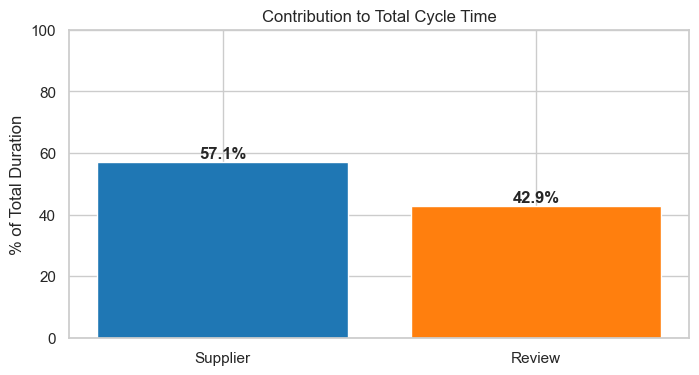

In [59]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(["Supplier", "Review"], [supplier_pct, review_pct], color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel("% of Total Duration")
ax.set_ylim(0,100)
ax.set_title("Contribution to Total Cycle Time")
for i, v in enumerate([supplier_pct, review_pct]):
    ax.text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

In [22]:
bottleneck = "Review" if review_pct > supplier_pct else "Supplier"
display(Markdown(f"**Main Bottleneck:** {bottleneck} phase ({max(review_pct, supplier_pct):.1f}% of total cycle time)"))

**Main Bottleneck:** Supplier phase (57.1% of total cycle time)

In [23]:
# ## 7b. Supplier Submission Performance

# Assign supplier names, internal if missing
valid["SupplierName"] = valid["Select List 5"].fillna("Internal")

# Aggregate by supplier
supplier_perf = valid.groupby("SupplierName").agg(
    Total_Docs=("Document No", "count"),
    OnTime_Docs=("SupplierOnTime", lambda x: x.sum()),
    Delayed_Docs=("SupplierOnTime", lambda x: (~x).sum()),
    Avg_Delay=("SupplierDelay", "mean"),
    Max_Delay=("SupplierDelay", "max")
)

# Sort suppliers by number of delayed docs descending
supplier_perf = supplier_perf.sort_values("Delayed_Docs", ascending=False)

# Calculate on-time %
supplier_perf["OnTime_%"] = (supplier_perf["OnTime_Docs"] / supplier_perf["Total_Docs"] * 100).round(1)
supplier_perf["Avg_Delay"] = supplier_perf["Avg_Delay"].round(1)
supplier_perf["Max_Delay"] = supplier_perf["Max_Delay"].fillna(0).astype(int)

## 3. Supplier Submission Performance

In [56]:
# Display styled table
display(Markdown(
    "This table shows how each supplier (or internal documents) performed in terms of submissions relative to the planned dates:"
))

styled_supplier = (
    supplier_perf[["Total_Docs","OnTime_Docs","Delayed_Docs","OnTime_%","Avg_Delay","Max_Delay"]]
    .style
    .format({
        "OnTime_%": "{:.1f}%",
        "Avg_Delay": "{:.1f}",
        "Max_Delay": "{:.0f}"
    })
    # Medium Delays = bad
    .background_gradient(subset=["Delayed_Docs"], cmap="Reds")
    
    # 🟢 On-time = good (reverse so high = green)
    .background_gradient(subset=["OnTime_%"], cmap="RdYlGn")
    
    # Optional: also highlight delays severity
    .background_gradient(subset=["Avg_Delay"], cmap="Oranges")
    
    # Layout improvements
    .set_table_styles([
        {"selector": "table", "props": [("width", "100%")]},
        {"selector": "th", "props": [("font-size", "12pt"), ("padding", "8px")]},
        {"selector": "td", "props": [("font-size", "11pt"), ("padding", "8px")]},
        {"selector": "th.row_heading", "props": [("min-width", "200px"), ("text-align", "left")]},
    ])
    .set_properties(subset=["Total_Docs","OnTime_Docs","Delayed_Docs"], **{"min-width": "100px", "text-align": "center"})
    .set_properties(subset=["OnTime_%"], **{"min-width": "120px", "text-align": "center"})
    .set_properties(subset=["Avg_Delay","Max_Delay"], **{"min-width": "100px", "text-align": "center"})
)

display(styled_supplier)

This table shows how each supplier (or internal documents) performed in terms of submissions relative to the planned dates:

,Total_Docs,OnTime_Docs,Delayed_Docs,OnTime_%,Avg_Delay,Max_Delay
SupplierName,,,,,,
GIDNA,261,27,234,10.3%,96.6,544
INNOVATIVE BUILDING SOLUTIONS,18,0,18,0.0%,248.6,354
JET Contractor,28,28,0,100.0%,0.0,0


## 4. Submission vs Approval Trend

In [25]:
flow = df.dropna(subset=["FirstDateIn", "ApprovedDate"]).copy()
flow["Week_Sub"] = flow["FirstDateIn"].dt.to_period("W").dt.start_time
flow["Week_App"] = flow["ApprovedDate"].dt.to_period("W").dt.start_time

In [26]:
submitted = flow.groupby("Week_Sub").size()
approved = flow.groupby("Week_App").size()
trend = pd.concat([submitted, approved], axis=1).fillna(0)
trend.columns = ["Submitted", "Approved"]
trend["Backlog"] = (trend["Submitted"] - trend["Approved"]).cumsum()

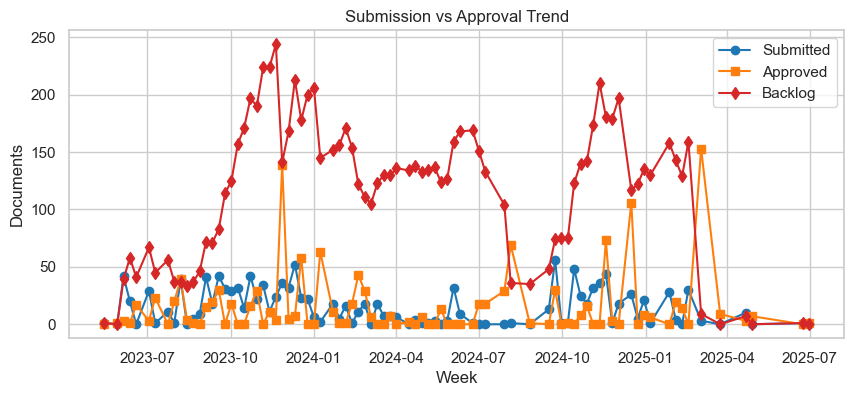

In [54]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(trend.index, trend['Submitted'], marker='o', label='Submitted', color='#1f77b4')
ax.plot(trend.index, trend['Approved'], marker='s', label='Approved', color='#ff7f0e')
ax.plot(trend.index, trend['Backlog'], marker='d', label='Backlog', color='#d62728')
ax.set_xlabel("Week")
ax.set_ylabel("Documents")
ax.set_title("Submission vs Approval Trend")
ax.legend()
plt.show()

In [28]:
display(Markdown(f"**Current Backlog:** {int(trend['Backlog'].iloc[-1])} documents"))

**Current Backlog:** 0 documents

## 5. Discipline Risk Analysis

In [29]:
df_sla = df.dropna(subset=["DueDate","ApprovedDate"]).copy()
df_sla["Delay"] = (df_sla["ApprovedDate"] - df_sla["DueDate"]).dt.days.clip(lower=0)

In [30]:
risk = df_sla.groupby("Select List 1").agg(
    Total=("Document No", "count"),
    Late=("Delay", lambda x: (x>0).sum())
)
risk["Breach_%"] = risk["Late"] / risk["Total"] * 100
risk = risk.sort_values("Breach_%", ascending=False)

In [31]:
top_risk = risk.head(10)
y_pos = np.arange(len(top_risk.index))
colors = ['#d62728' if x>50 else '#ff7f0e' if x>30 else '#2ca02c' for x in top_risk['Breach_%']]

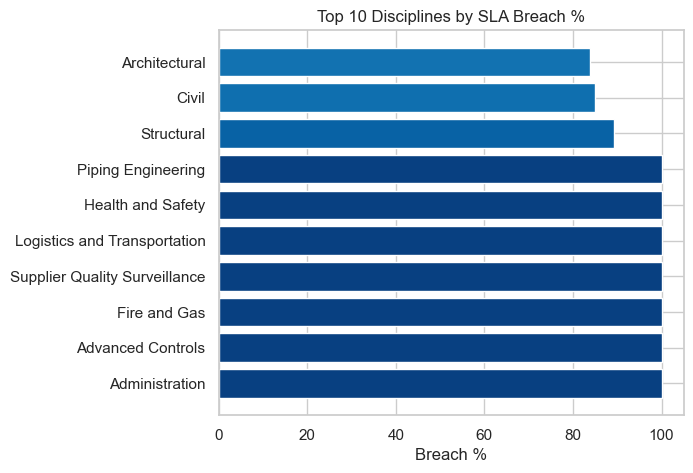

In [52]:
# Create color gradient based on Breach %
norm = plt.Normalize(0, top_risk['Breach_%'].max())
cmap = plt.cm.GnBu  # you can try: 'Blues', 'GnBu', 'PuBu'

colors = cmap(norm(top_risk['Breach_%']))

# Original chart (kept same)
fig, ax = plt.subplots(figsize=(6,5))
ax.barh(y_pos, top_risk['Breach_%'], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_risk.index)
ax.set_xlabel("Breach %")
ax.set_title("Top 10 Disciplines by SLA Breach %")
plt.show()

In [33]:
display(Markdown("**Top 3 Risk Disciplines:**"))
# ## Top Risk Disciplines (Styled)

top3 = top_risk.head()

styled_top3 = (
    top3
    .style
    .format({
        "Breach_%": "{:.1f}%",
        "Total": "{:.0f}",
        "Late": "{:.0f}"
    })
    .background_gradient(subset=["Breach_%"], cmap="Reds")
    .background_gradient(subset=["Late"], cmap="Oranges")
    .background_gradient(subset=["Total"], cmap="Blues")
    .set_table_styles([
        {"selector": "table", "props": [("width", "100%")]},
        {"selector": "th", "props": [("font-size", "12pt"), ("padding", "8px")]},
        {"selector": "td", "props": [("font-size", "11pt"), ("padding", "8px")]},
        {"selector": "th.row_heading", "props": [("min-width", "220px"), ("text-align", "left")]},
    ])
    .set_properties(subset=["Total"], **{"min-width": "120px", "text-align": "center"})
    .set_properties(subset=["Late"], **{"min-width": "120px", "text-align": "center"})
    .set_properties(subset=["Breach_%"], **{"min-width": "140px", "text-align": "center"})
)

display(styled_top3)

**Top 3 Risk Disciplines:**

,Total,Late,Breach_%
Select List 1,,,
Administration,2,2,100.0%
Advanced Controls,2,2,100.0%
Fire and Gas,4,4,100.0%
Supplier Quality Surveillance,2,2,100.0%
Logistics and Transportation,1,1,100.0%


### Detailed Discipline Risk Heatmap

In [63]:
# ## 5c. Detailed Discipline Risk Table (Improved Layout)

styled_risk = (
    risk.sort_values("Breach_%", ascending=False).head(12)
    .style
    .format({
        "Breach_%": "{:.1f}%",
        "Total": "{:.0f}",
        "Late": "{:.0f}"
    })
    .background_gradient(subset=["Breach_%"], cmap="Reds")
    .background_gradient(subset=["Late"], cmap="Oranges")
    .background_gradient(subset=["Total"], cmap="Blues")
    .set_table_styles([
        {"selector": "table", "props": [("width", "100%")]},
        {"selector": "th", "props": [("font-size", "12pt"), ("padding", "8px")]},
        {"selector": "td", "props": [("font-size", "11pt"), ("padding", "8px")]},
    ])
    .set_properties(subset=["Total"], **{"min-width": "160px"})
    .set_properties(subset=["Late"], **{"min-width": "160px"})
    .set_properties(subset=["Breach_%"], **{"min-width": "180px"})
)

display(Markdown("### Detailed Discipline Risk Data"))
display(styled_risk)

### Detailed Discipline Risk Data

,Total,Late,Breach_%
Select List 1,,,
Administration,2,2,100.0%
Advanced Controls,2,2,100.0%
Fire and Gas,4,4,100.0%
Supplier Quality Surveillance,2,2,100.0%
Logistics and Transportation,1,1,100.0%
Health and Safety,6,6,100.0%
Piping Engineering,32,32,100.0%
Structural,56,50,89.3%
Civil,406,345,85.0%


## 6. Reviewer Performance

In [35]:
df_rev = df.dropna(subset=["FirstDateIn","ApprovedDate","Assigned_To"]).copy()
df_rev["ReviewDays"] = (df_rev["ApprovedDate"] - df_rev["FirstDateIn"]).dt.days

In [36]:
reviewer_data = []
for reviewer in df_rev["Assigned_To"].unique():
    reviewer_docs = df_rev[df_rev["Assigned_To"]==reviewer]
    if len(reviewer_docs)==0:
        continue
    first_review = reviewer_docs["FirstDateIn"].min()
    last_review = reviewer_docs["ApprovedDate"].max()
    days_active = max((last_review - first_review).days, 1)
    weeks_active = days_active/7
    throughput = len(reviewer_docs)/weeks_active
    reviewer_data.append({
        "Reviewer": reviewer,
        "Count": len(reviewer_docs),
        "Avg_Days": reviewer_docs["ReviewDays"].mean(),
        "OnTime_%": reviewer_docs["ReviewerOnTime"].mean()*100,
        "Docs_per_Week": throughput,
        "Days_Active": days_active,
        "Weeks_Active": weeks_active
    })

In [64]:
review_perf=pd.DataFrame(reviewer_data).sort_values("Docs_per_Week",ascending=False).set_index("Reviewer").head(12)
display(Markdown("## Reviewer Performance"))
display(Markdown("Reviewer throughput, average review days, and SLA compliance."))
display(review_perf.style.background_gradient(subset=["OnTime_%"], cmap="Greens"))

## Reviewer Performance

Reviewer throughput, average review days, and SLA compliance.

,Count,Avg_Days,OnTime_%,Docs_per_Week,Days_Active,Weeks_Active
Reviewer,,,,,,
Mr Sami Benjelloun - NY ARCHITECTURE,898,58.884187,10.133630,10.582492,594,84.857143
"Hamid El Allali - JESA SA, Mr Lahcen El Haddaoui - JESA SA",18,4.111111,61.111111,9.000000,14,2.000000
ABDELMOUMEN LABHAR - JESA SA,164,80.109756,82.317073,2.720379,422,60.285714
Mr Rachid Ait Kassi - JESA SA,17,10.058824,17.647059,1.144231,104,14.857143
"Mr Lahcen El Haddaoui - JESA SA, Naoufal Safaa - JESA SA",1,7.000000,0.000000,1.000000,7,1.000000
Mr Salah Aniba - JESA SA,1,7.000000,100.000000,1.000000,7,1.000000
"ABDELMOUMEN LABHAR - JESA SA, Mostapha Habiballah - JESA SA",8,38.375000,37.500000,0.982456,57,8.142857
Mr Khalid ECHBARTHI - JESA SA,37,32.675676,0.000000,0.817035,317,45.285714
Hamid El Allali - JESA SA,12,10.666667,0.000000,0.666667,126,18.000000


## 7. Review Duration Distribution (Detailed + Beautified)

In [38]:
dist = df_rev["ReviewDays"].dropna()
bins = [0,5,10,20,100]
labels = ["0-5","6-10","11-20","20+"]

In [39]:
bucket = pd.cut(dist, bins=bins, labels=labels, right=False)
counts = bucket.value_counts().sort_index()
percentages = (counts/counts.sum()*100).round(1)

Chart

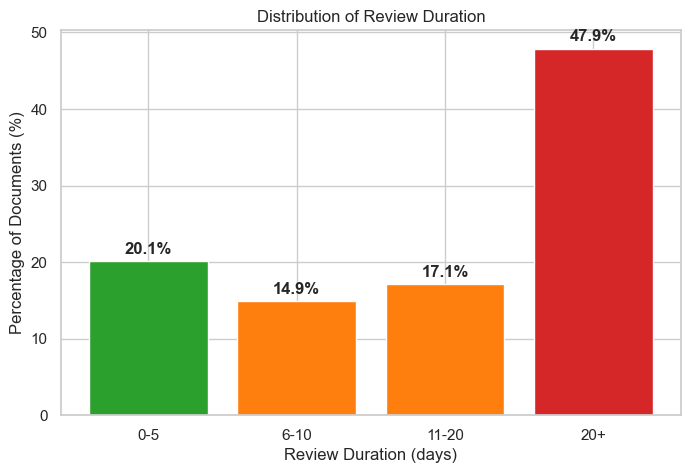

In [40]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(labels, percentages, color=['#2ca02c','#ff7f0e','#ff7f0e','#d62728'])
ax.set_xlabel("Review Duration (days)")
ax.set_ylabel("Percentage of Documents (%)")
ax.set_title("Distribution of Review Duration")
for i, v in enumerate(percentages):
    ax.text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

In [41]:
display(Markdown("### Review Duration Summary"))
display(Markdown(
    "The chart above shows the percentage of documents completed within different review durations:\n"
    "- **0-5 days:** Fast reviews\n"
    "- **6-10 days:** Normal duration\n"
    "- **11-20 days:** Slow reviews\n"
    "- **20+ days:** Very slow reviews; potential bottlenecks, investigate these documents"
))
dist_table = pd.DataFrame({
    "Duration Range": labels,
    "Document Count": counts.values,
    "Percentage (%)": percentages
})
display(dist_table)

### Review Duration Summary

The chart above shows the percentage of documents completed within different review durations:
- **0-5 days:** Fast reviews
- **6-10 days:** Normal duration
- **11-20 days:** Slow reviews
- **20+ days:** Very slow reviews; potential bottlenecks, investigate these documents

,Duration Range,Document Count,Percentage (%)
ReviewDays,,,
0-5,0-5,194,20.1
6-10,6-10,144,14.9
11-20,11-20,165,17.1
20+,20+,463,47.9


In [42]:
# Ensure arrays match
min_len = min(len(labels), len(counts), len(percentages))
dist_table = pd.DataFrame({
    "Duration Range": labels[:min_len],
    "Document Count": counts.values[:min_len],
    "Percentage (%)": percentages[:min_len]
})

# Subtle highlight styling
styled_table = (
    dist_table.style
    .format({"Percentage (%)": "{:.2f}%"})  # format percentages
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '13pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center')]}
    ])
    # Highlight top 1 value in Document Count
    .highlight_max(subset=["Document Count"], color="#d4edda")  # light green
    # Highlight top 1 value in Percentage
    .highlight_max(subset=["Percentage (%)"], color="#fff3cd")  # light yellow
    .set_caption("📊 Document Duration Distribution")
)

display(styled_table)

,Duration Range,Document Count,Percentage (%)
ReviewDays,,,
0-5,0-5,194,20.10%
6-10,6-10,144,14.90%
11-20,11-20,165,17.10%
20+,20+,463,47.90%


## 8. Dynamic Action Plan

In [43]:
def get_dynamic_actions(results, supplier_perf):
    """Generate dynamic action items with supplier context and readable insights"""
    actions = []

    # --- 1. Time contribution analysis ---
    if results['review_pct'] > results['supplier_pct']:
        actions.append({
            "priority": "🔴" if results['review_pct'] > 70 else "🟠",
            "category": "Review Process Bottleneck",
            "action": f"Review contribution ({results['review_pct']:.1f}%) exceeds supplier contribution ({results['supplier_pct']:.1f}%). Consider:",
            "items": [
                "Increase reviewer capacity or redistribute workload",
                "Implement priority queuing for urgent documents",
                "Review and streamline approval workflows"
            ]
        })
    else:
        # --- 2. Supplier Delay Dominant with text explanation ---
        max_delays = supplier_perf["Delayed_Docs"].max()
        top_late_suppliers = supplier_perf[supplier_perf["Delayed_Docs"] == max_delays].index.tolist()
        never_ontime = supplier_perf[supplier_perf["OnTime_%"] == 0].index.tolist()

        if len(never_ontime) > 0:
            insight_text = (
                f"- Supplier(s) with the **most delayed documents ({max_delays})**: {', '.join(top_late_suppliers)}. "
                f"These suppliers may need follow-up to improve submission timeliness.\n"
                f"- Suppliers that were **never on time**: {', '.join(never_ontime)}. Might check the schedule with them."
            )
        else:
            insight_text = (
                "From the supplier submission performance, you can see:\n"
                f"- Supplier(s) with the **most delayed documents ({max_delays})**: {', '.join(top_late_suppliers)}.\n"
                "- All suppliers have at least some on-time submissions."
            )

        actions.append({
            "priority": "🔴" if results['supplier_pct'] > 70 else "🟠",
            "category": "Supplier Delay Dominant",
            "action": f"Supplier delay ({results['supplier_pct']:.1f}%) is the main contributor.",
            "insight": insight_text
        })

    # --- 3. Backlog analysis ---
    if results['backlog'] > 20:
        actions.append({
            "priority": "🔴",
            "category": "High Backlog Pressure",
            "action": f"*Backlog pressure* is {results['backlog']:.1f}% (target <20%). Immediate actions required:",
            "items": [
                "Organize a backlog clearing session",
                "Temporarily reassign resources to review queue",
                "Prioritize oldest documents first"
            ]
        })
    elif results['backlog'] > 10:
        actions.append({
             "priority": "🟠",
            "category": "Moderate Backlog Pressure",
            "action": f"*Backlog pressure* is {results['backlog']:.1f}%. Monitor closely:",
            "items": [
                "Track weekly trend to ensure it doesn't increase",
                "Review if current capacity can handle incoming volume"
            ]
        })

    # --- 4. Discipline risk analysis ---
    if not results['risk'].empty:
        top_discipline = results['risk'].index[0]
        top_breach = results['risk'].iloc[0]['Breach_%']

        if top_breach > 50:
            actions.append({
                "priority": "🔴",
                "category": "Critical Discipline Risk",
                "action": f"'{top_discipline}' has {top_breach:.1f}% breach rate. Immediate focus required:",
                "items": [
                    f"Review all documents from {top_discipline} discipline",
                    "Meet with discipline leads to understand root causes",
                    "Consider temporary additional support for this area"
                ]
            })
        elif top_breach > 30:
            actions.append({
                 "priority": "🟠",
                "category": "Discipline Risk",
                "action": f"'{top_discipline}' has {top_breach:.1f}% breach rate. Action needed:",
                "items": [
                    f"Monitor {top_discipline} documents closely",
                    "Identify patterns in delayed reviews",
                    "Provide targeted support to reviewers in this discipline"
                ]
            })

    # --- 5. Reviewer performance analysis ---
    if not results['review_perf'].empty:
        avg_throughput = results['review_perf']['Docs_per_Week'].mean()
        slow_reviewers = results['review_perf'][results['review_perf']['Docs_per_Week'] < avg_throughput * 0.5]

        if len(slow_reviewers) > 0:
            names_list = slow_reviewers.index.tolist()
            chunk_size = 4
        
            # Split names into lines of 4
            name_lines = []
            for i in range(0, len(names_list), chunk_size):
                chunk = names_list[i:i+chunk_size]
                name_lines.append(", ".join(chunk))
        
            # Join lines with <br> for proper multi-line display in Markdown
            reviewers_text = "Reviewers:<br>" + "<br>".join(name_lines)
        
            # Prepare items list
            items_list = [
                reviewers_text,
                "Check if they need additional training or support",
                "Review their workload distribution"
            ]
        
            actions.append({
                "priority": "🟠",
                "category": "Low Throughput Reviewers",
                "action": f"{len(slow_reviewers)} reviewers have below-average throughput:",
                "items": items_list
            })
            
    # --- Backlog good section ---
    if results['backlog'] <= 10:
        actions.append({
            "priority": "🟢",
            "category": "Backlog Pressure Low",
            "action": f"Backlog is {results['backlog']:.1f}%, which is within target. Keep monitoring.",
            "items": [
                "Maintain current review capacity",
                "Continue tracking weekly trends"
            ]
        })
    
    # --- Discipline good section ---
    if results['risk'].empty or results['risk']['Breach_%'].max() <= 30:
        actions.append({
            "priority": "🟢",
            "category": "Discipline Performance Healthy",
            "action": "All disciplines have breach rates within acceptable limits.",
            "items": [
                "No immediate action required",
                "Maintain current document review standards"
            ]
        })
    
    return actions

In [44]:
results = {
    "supplier_pct": supplier_pct,
    "review_pct": review_pct,
    "backlog": backlog,
    "risk": risk,
    "review_perf": review_perf
}


In [45]:
# Generate dynamic actions
dynamic_actions = get_dynamic_actions(results, supplier_perf)

# Display dynamic actions neatly
for act in dynamic_actions:
    # --- Header with priority and category ---
    display(Markdown(f"**{act['priority'].capitalize()} {act['category']}**"))
    
    # --- Main action text ---
    display(Markdown(act["action"]))

    # --- Insight text, if present ---
    if "insight" in act:
        insight_lines = act["insight"].split("\n")  # handle multi-line insights
        for line in insight_lines:
            display(Markdown(f"  {line}"))  # slight indent for readability

    # --- Items (bullet points), if present ---
    if "items" in act:
        for item in act["items"]:
            display(Markdown(f"  - {item}"))  # properly indented bullet points

    # --- Optional separator between actions ---
    display(Markdown("---"))

**🟠 Supplier Delay Dominant**

Supplier delay (57.1%) is the main contributor.

  - Supplier(s) with the **most delayed documents (234)**: GIDNA. These suppliers may need follow-up to improve submission timeliness.

  - Suppliers that were **never on time**: INNOVATIVE BUILDING SOLUTIONS. Might check the schedule with them.

---

...

12 reviewers have below-average throughput:

  - Reviewers:<br>Mr Khalid ECHBARTHI - JESA SA,  Hamid El Allali - JESA SA, Mr Amine Moutakid - JESA SA, Mr Kamal Nait Khachat - JESA SA<br>Mr Lahcen El Haddaoui - JESA SA,  Hicham Bouakil - JESA SA, Mr Abdelazize Mouchina - JESA SA,  Omar Zouhri - JESA SA<br>Ms Malak SADIQ - JESA SA,  Hicham Bouakil - JESA SA, Mr Lahcen El Haddaoui - JESA SA, Mr Abdessamd Zaouia - JESA SA,  Naoufal Safaa - JESA SA

  - Check if they need additional training or support

  - Review their workload distribution

---